# Optimized Machine Learning Model for Predicting and Analyzing Accelerations in the New Ground Motion Models for Northern South America (NoSAm GMMs)

La ingenieria sismica es uno de los principales campos frente a la evaluación de riesgos y vulnerabilidad a partir de los desastres naturales, en este caso en específico, los sismos. Teniendo en cuenta variables como la magnitud sísmica (Momento Magnitude Mw), la distancia al hipocentro y el entorno tectónico, se busca predecir la aceleración espectral con un periodo de 0.01 s producidas por los sismos, con el objetivo de obtener un modelo confiable capaz de predecir la aceleración con periodos distintos. 
Los modelos anteriores (NoSAm GMMs) permitieron la estimación de la aceleración espectral con 5% de amortiguamiento en diferentes entornos tectónicos.
 Para ello, se utilizará una base de datos regional con aproximadamente 8800 observaciones recogidas por el Servicio Geológico Colombiano el cual incluye registros de Ecuador y Colombia. A partir de allí se compararán modelos tradicionales de Machine Learning (como KNN, regresión Ridge y Lasso, SVM y XGBoost) con un modelo original de stacking basado en modelos de XGBoost y LightGBM, con el objetivo de mejorar la precisión de predicción respecto a estudios previos y a su vez comparar las métricas generales con los modelos preliminares.

**Palabras clave**:
 ingeniería sismica, aceleración espectral, Machine Learning, predicción, riesgos, vulnerabilidad, desastres naturales, periodo



## 1. Análisis Exploratorio de datos  (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score, explained_variance_score

import scipy.stats as stats
from scipy.stats import kurtosis, boxcox

import mglearn
import matplotlib

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:/Users/elias/OneDrive/Desktop/MachineLearning/MLProject/Copia de DataBaseSGC.csv', delimiter=';', low_memory=False)
df

,Record Sequence Number,EQID,Epicenter Latitude (deg; positive N),Epicenter Longitude (deg; positive E),Hypocenter Depth (km),Magnitude,Magnitude type,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Nodal Plane 1 Strike (deg),Nodal Plane 1 Dip (deg),...,Station Elevation (m),Tmax,Valor_T1.5,Repi_OpenQuake,Rjb_OpenQuake,Rrup_OpenQuake,Rx_OpenQuake,Rhypo_OpenQuake,Ry0_OpenQuake,T_0.01_RotD50
0,73,CO_20080524192044,4.374,-73.708,14.7,5.8671,Mw,Crustal,196,82,...,581.0,14,0.07,91.480436,85.352392,86.623229,5.748244,93.551751,85.165829,4.755494
1,74,CO_20100729193445,3.907,-75.097,33.1,5.0567,Mw,Crustal,37,54,...,581.0,15,0.05,96.319115,93.725261,99.461616,8.545095,102.497369,93.435791,10.887828
2,76,CO_19940913100134,7.105,-76.665,14.0,6.0202,Mw,Crustal,4,64,...,1472.0,2,0.09,180.238872,173.579980,174.684394,95.953705,181.353681,146.630792,4.847060
3,79,CO_19961104172500,7.364,-77.380,14.0,6.2562,Mw,Crustal,188,43,...,1472.0,2,0.10,253.961289,244.155697,244.405678,-188.792092,254.752031,154.796223,1.814338
4,84,CO_19990125181918,4.445,-75.659,17.0,6.1355,Mw,Crustal,8,65,...,1472.0,3,0.07,139.662026,134.252237,135.354859,-121.819668,141.709990,56.434882,9.462926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8806,8774,CO_20190331072713,-1.910,-80.810,5.0,5.6000,Mw,Interface,337,24,...,696.0,27,0.02,1236.021754,1230.674634,1230.049890,1178.334392,1236.043904,374.756057,0.004725
8807,8776,CO_20190331140913,-2.030,-80.890,10.0,5.0181,Mw,Interface,354,21,...,696.0,27,0.02,1253.442350,1249.197259,1248.234684,1023.671482,1253.495004,717.168683,0.003128
8808,8777,CO_20190408032300,-2.120,-80.360,47.0,5.0304,Mw,Interface,334,31,...,696.0,27,0.02,1216.435655,1213.141652,1209.579637,1162.208344,1217.416127,358.488368,0.003101
8809,8778,CO_20190409113955,3.750,-78.740,10.0,5.0266,Mw,Interface,26,32,...,696.0,20,0.02,729.062638,725.469563,725.018483,-469.472251,729.171353,552.584146,0.020313


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8811 entries, 0 to 8810
Data columns (total 30 columns):
 #   Column                                                                                    Non-Null Count  Dtype  
---  ------                                                                                    --------------  -----  
 0   Record Sequence Number                                                                    8811 non-null   int64  
 1   EQID                                                                                      8811 non-null   object 
 2   Epicenter Latitude (deg; positive N)                                                      8811 non-null   float64
 3   Epicenter Longitude (deg; positive E)                                                     8811 non-null   float64
 4   Hypocenter Depth (km)                                                                     8811 non-null   float64
 5   Magnitude                                              

**Identificación de cada variable del conjunto de datos**<br><br>
**EQID**: Identificador único del evento sísmico.<br>
**Epicenter Latitude (deg; positive N)**: Latitud del epicentro en grados (positiva hacia el norte).<br>
**Epicenter Longitude (deg; positive E)**: Longitud del epicentro en grados (positiva hacia el este).<br>
**Hypocenter Depth (km)**: Profundidad del hipocentro en kilómetros.<br>
**Magnitude**: Magnitud del sismo.<br>
**Magnitude type**: Tipo de magnitud (por ejemplo, ML, MW, MS, MB).<br>
**Tectonic environment**: Entorno tectónico del sismo (Crustal, Inslab, Interface, Stable, Deep, Volcanic, Oceanic Crust).<br>
**Nodal Plane 1 Strike (deg)**: Ángulo de rumbo del primer plano nodal en grados.<br>
**Nodal Plane 1 Dip (deg)**: Ángulo de buzamiento del primer plano nodal en grados.<br>
**Nodal Plane 1 Rake Angle (deg)**: Ángulo de deslizamiento del primer plano nodal en grados.<br>
**Nodal Plane 2 Strike (deg)**: Ángulo de rumbo del segundo plano nodal en grados.<br>
**Nodal Plane 2 Dip (deg)**: Ángulo de buzamiento del segundo plano nodal en grados.<br>
**Nodal Plane 2 Rake Angle (deg)**: Ángulo de deslizamiento del segundo plano nodal en grados.<br>
**Fault Plane (1; 2; X)**: Plano de falla utilizado para el análisis (1 o 2, X si es desconocido).<br>
**Style-of-Faulting (S; R; N; U)**: Estilo de falla (S: Strike-slip, R: Reverse, N: Normal, U: Desconocido).<br>
**Station ID**: Identificador único de la estación sísmica.<br>
**Station Code**: Código de la estación sísmica.<br>
**Station Latitude (deg positive N)**: Latitud de la estación sísmica en grados (positiva hacia el norte).<br>
**Station Longitude (deg positive E)**: Longitud de la estación sísmica en grados (positiva hacia el este).<br>
**Station Elevation (m)**: Elevación de la estación sísmica en metros.<br>
**Tmax**: Valor máximo del período de vibración analizado.<br>
**Valor_T1.5**: Valor del parámetro sísmico en el período de 1.5 segundos.<br>
**Repi_OpenQuake**: Distancia epicentral (distancia horizontal desde el epicentro a la estación).<br>
**Rjb_OpenQuake**: Distancia de Joyner-Boore (distancia horizontal desde la estación a la proyección de la falla).<br>
**Rrup_OpenQuake**: Distancia de ruptura (distancia mínima entre la estación y la superficie de la falla).<br>
**Rx_OpenQuake**: Coordenada horizontal de la estación en relación con la falla.<br>
**Rhypo_OpenQuake**: Distancia hipocentral (distancia tridimensional desde la estación hasta el hipocentro).<br>
**Ry0_OpenQuake**: Distancia perpendicular a la dirección de deslizamiento de la falla.<br>
**T_0.01_RotD50**: Aceleración espectral en el período de 0.01 segundos utilizando la métrica RotD50.<br>

Se identifican las variables categóricas.

In [4]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['EQID', 'Magnitude type',
       'Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)',
       'Style-of-Faulting (S; R; N; U)', 'Station ID', 'Station Code'],
      dtype='object')

Se eliminan algunas variables que no aportan para reducir la dimensión del dataframe.<br>
En este caso el único valor que posee Magnitude type es Mw que indica la escala en la que se reportan los valores de las magnitudes de los sismos.<br>
Así también se elimina la variable Record Sequence Number ya que presenta un conteo de la cantidad de sismos registrados. <br>

In [5]:
df['Magnitude type'].value_counts()

Magnitude type
Mw    8811
Name: count, dtype: int64

In [6]:
df.drop(["Record Sequence Number"], axis=1, inplace=True)
df.drop(["Magnitude type"], axis=1, inplace=True)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Epicenter Latitude (deg; positive N),8811.0,5.896834,3.759842,-4.825000,3.440000,6.535500,7.280000,13.260000
Epicenter Longitude (deg; positive E),8811.0,-76.241968,2.851960,-81.260000,-78.290000,-76.040000,-73.280000,-67.973000
Hypocenter Depth (km),8811.0,59.993065,62.345192,1.000000,10.000000,19.600000,132.000000,209.900000
Magnitude,8811.0,4.988405,0.675945,3.800000,4.500000,4.900000,5.260000,7.782200
Nodal Plane 1 Strike (deg),8811.0,177.660651,106.265249,2.000000,88.000000,168.000000,265.000000,360.000000
Nodal Plane 1 Dip (deg),8811.0,58.328567,23.395038,1.000000,41.000000,65.000000,80.000000,90.000000
Nodal Plane 1 Rake Angle (deg),8811.0,13.555783,109.983810,-180.000000,-69.000000,20.000000,107.000000,180.000000
Nodal Plane 2 Strike (deg),8811.0,169.453978,108.282067,0.000000,71.000000,172.000000,258.000000,360.000000
Nodal Plane 2 Dip (deg),8811.0,68.298604,16.069385,14.000000,58.000000,69.000000,82.000000,90.000000
Nodal Plane 2 Rake Angle (deg),8811.0,18.638974,102.783054,-180.000000,-50.000000,18.000000,100.000000,177.000000


In [8]:
df.isnull().sum()

EQID                                                                                        0
Epicenter Latitude (deg; positive N)                                                        0
Epicenter Longitude (deg; positive E)                                                       0
Hypocenter Depth (km)                                                                       0
Magnitude                                                                                   0
Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)    0
Nodal Plane 1 Strike (deg)                                                                  0
Nodal Plane 1 Dip (deg)                                                                     0
Nodal Plane 1 Rake Angle (deg)                                                              0
Nodal Plane 2 Strike (deg)                                                                  0
Nodal Plane 2 Dip (deg)                                     

Es necesario también remover aquellas filas que presentan aceleración = 0 ya que no son importantes para el estudio realizado.

In [9]:
df = df[df['T_0.01_RotD50'] > 0]

Se hace uso de dos dataframes independientes como objetivo de comparar como se distribuyen las observaciones de las variables de forma original y haciendo uso de la transformación logarítmica.<br>
Las transformaciones algunas veces son necesarias para ajustar el comportamiento de los datos de manera que un modelo de Machine Learning como KNN pueda intepretarlos de manera correcta.


In [10]:
df_copy = df.copy()

In [11]:
df_copy["T_0.01_RotD50"]= np.log(df_copy["T_0.01_RotD50"])

Para el caso en particular de la variable de respuesta 

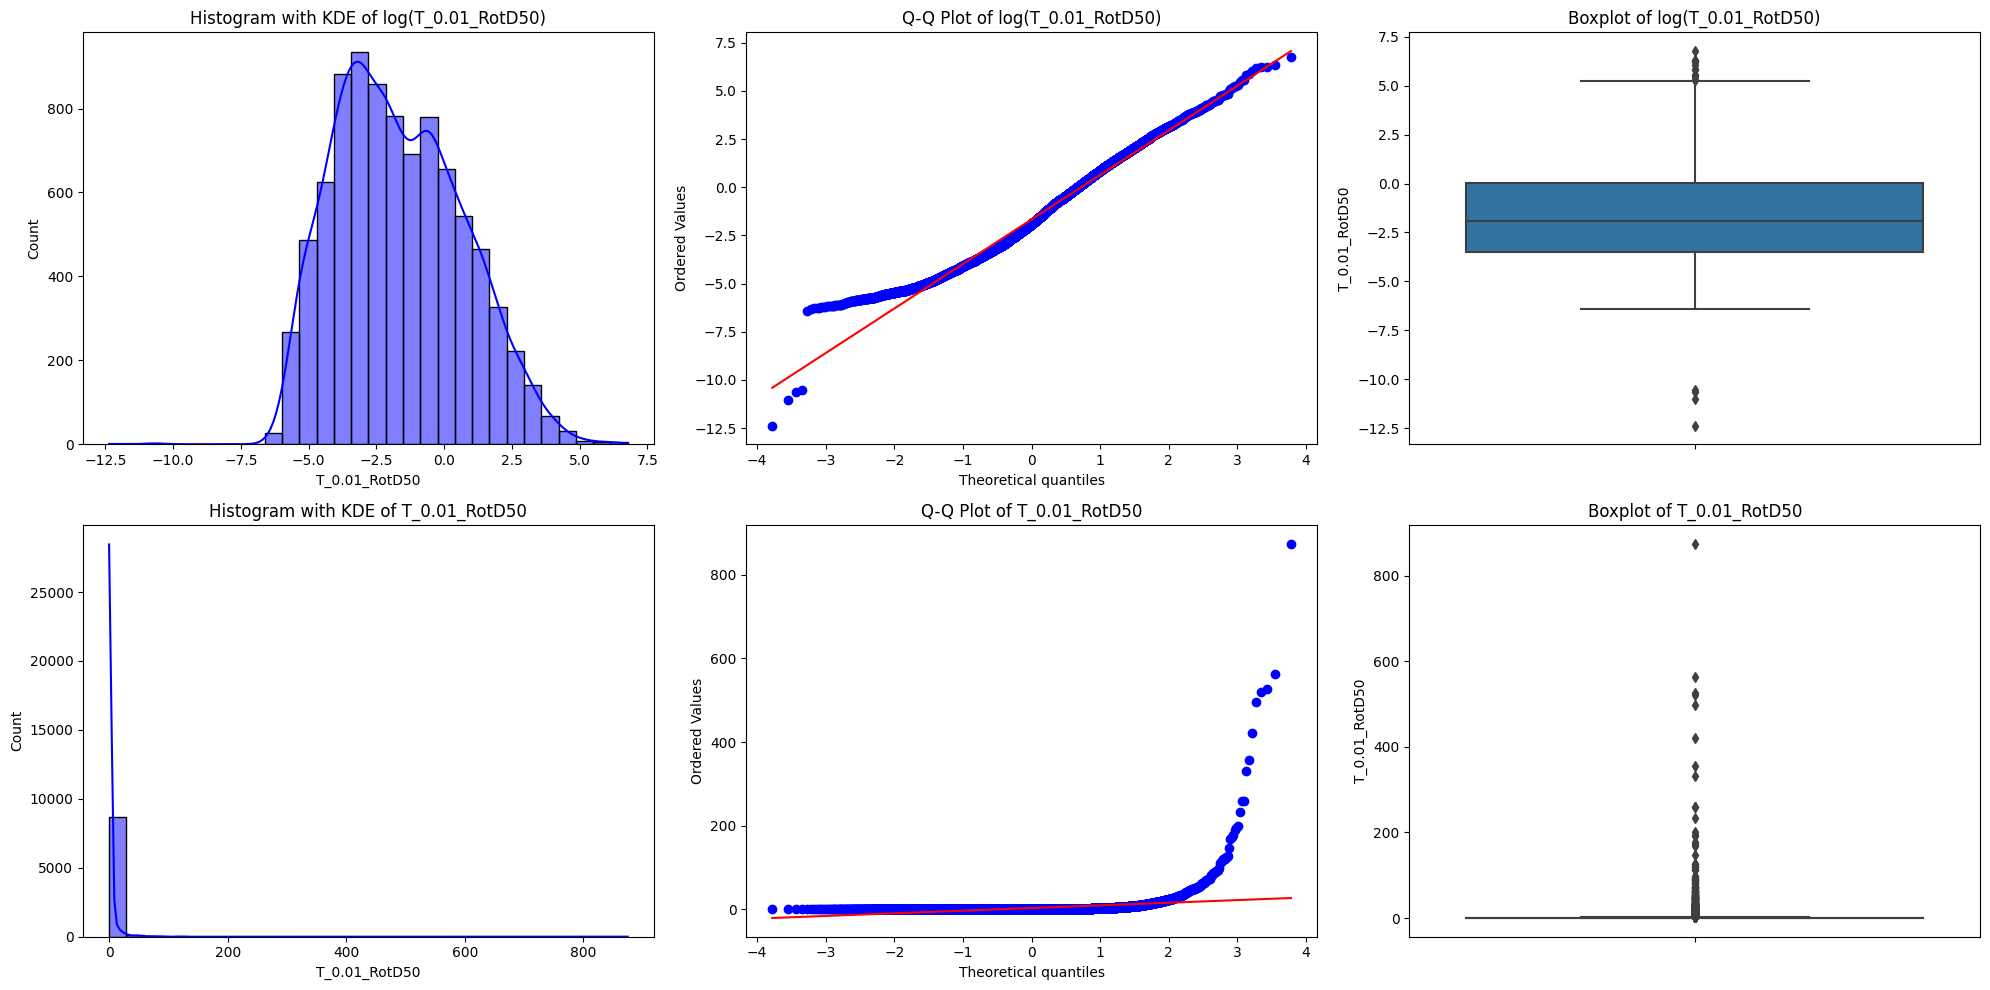

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))  # 2 filas, 3 columnas

sns.histplot(df_copy["T_0.01_RotD50"], kde=True, bins=30, color="blue", edgecolor="black", ax=axes[0][0])
axes[0][0].set_title("Histogram with KDE of log(T_0.01_RotD50)")

stats.probplot(df_copy["T_0.01_RotD50"], dist="norm", plot=axes[0][1])
axes[0][1].set_title("Q-Q Plot of log(T_0.01_RotD50)")

sns.boxplot(y=df_copy["T_0.01_RotD50"], ax=axes[0][2])
axes[0][2].set_title("Boxplot of log(T_0.01_RotD50)")

sns.histplot(df["T_0.01_RotD50"], kde=True, bins=30, color="blue", edgecolor="black", ax=axes[1][0])
axes[1][0].set_title("Histogram with KDE of T_0.01_RotD50")

stats.probplot(df["T_0.01_RotD50"], dist="norm", plot=axes[1][1])
axes[1][1].set_title("Q-Q Plot of T_0.01_RotD50")

sns.boxplot(y=df["T_0.01_RotD50"], ax=axes[1][2])
axes[1][2].set_title("Boxplot of T_0.01_RotD50")

plt.tight_layout()
plt.show()

Se puede evidenciar como mejora notablemente la distribución de la variable.<br>
A su vez, se logra identificar que existen datos atípicos en ambos grupos de datos que podrían afectar en las distribuciones.<br>
A partir de este punto se trabajará con el logaritmo de la aceleración espectral<br>

Es importante mencionar que en estudios anteriores también se ha realizado la transformación usando logaritmo natural tal como lo describe esta ecuación extraída de 

$$
\ln(\text{Sa}_{\text{RotD50}}) = \theta_1 + f_{\text{mag}}(M)_{\text{GL}} + f_{\text{mag}}(M)_{\text{REG}} 
+ f_{\text{path}}(M,R)_{\text{GL}} + f_{\text{path}}(R)_{\text{REG}} 
+ f_{\text{soil}}(S_{\text{cat}}, P^*)_{\text{REG}} + f_{\text{FABA}} + f_{Z_{\text{hypo}}}
$$

Donde $\text{Sa}_{\text{RotD50}}$ es la aceleración espectral

- **Análisis univariado**<br>

    - **Asimetría**<br><br>

        **skew = 0**: Distribución simétrica <br>
        **skew > 0**: Distribuido hacia cola izquierda (sesgo positivo).<br>
        **skew < 0**: Distribuido hacia cola derecha (sesgo negativo).<br><br>

    - **Kurtosis**: Forma de la distribución<br><br>

        **kurtosis = 3 (Mesocúrtica)**: Distribución normal.<br>
        **kurtosis < 3 (Platicúrtica)**: Distribución con colas menos gruesas que la normal.<br>
        **kurtosis > 3 (leptocúrtica)**: Distribución con colas más gruesas que la normal y con mayores valores atípicos<br>

Column:  Epicenter Latitude (deg; positive N)
Skew: 0.14
Kurtosis:  0.03


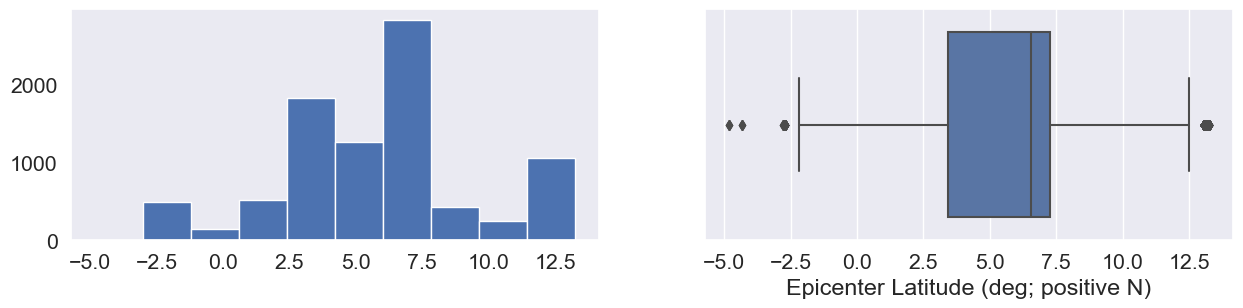

Column:  Epicenter Longitude (deg; positive E)
Skew: -0.31
Kurtosis:  -1.02


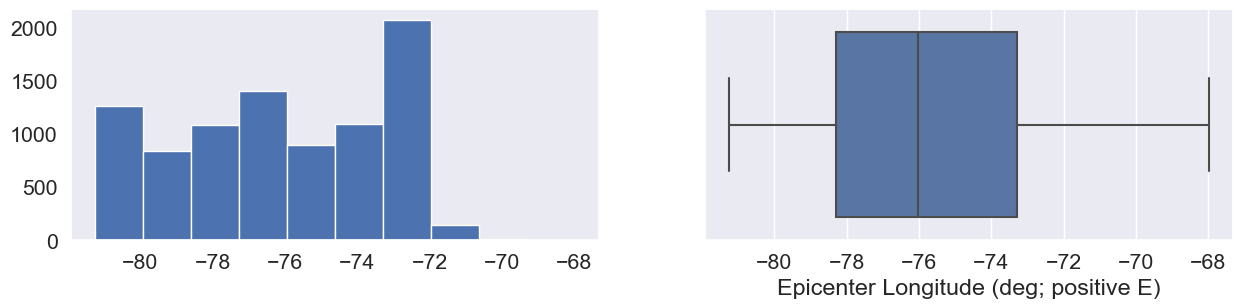

Column:  Hypocenter Depth (km)
Skew: 0.72
Kurtosis:  -1.21


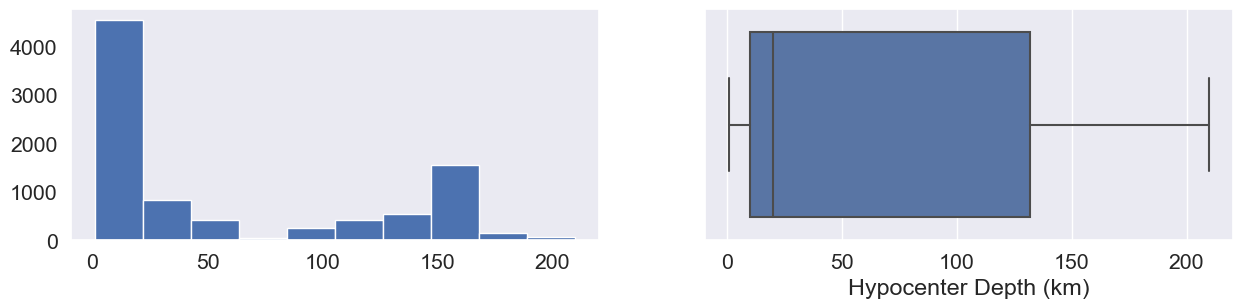

Column:  Magnitude
Skew: 1.24
Kurtosis:  2.12


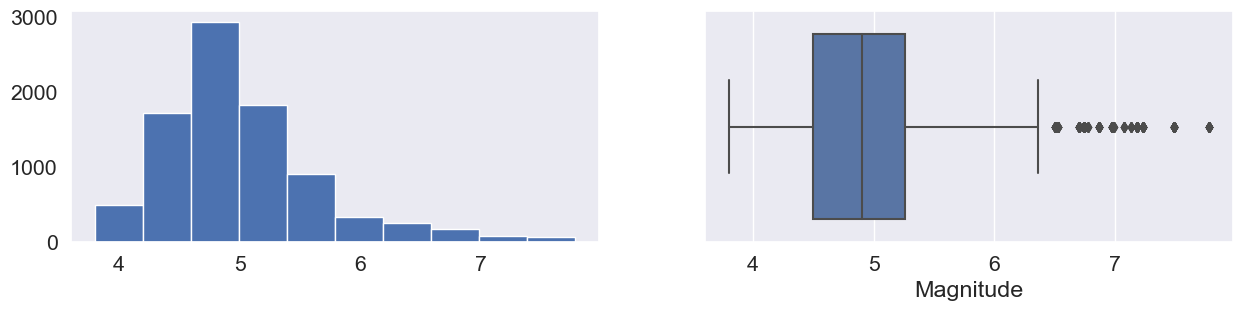

Column:  Nodal Plane 1 Strike (deg)
Skew: 0.09
Kurtosis:  -1.15


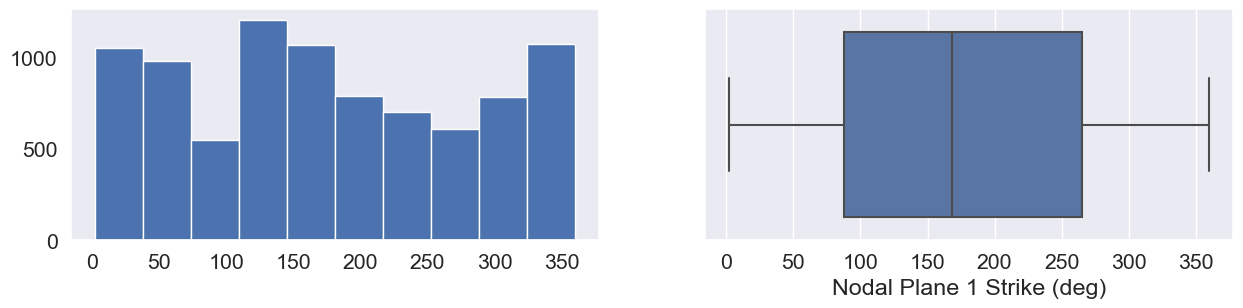

Column:  Nodal Plane 1 Dip (deg)
Skew: -0.47
Kurtosis:  -0.95


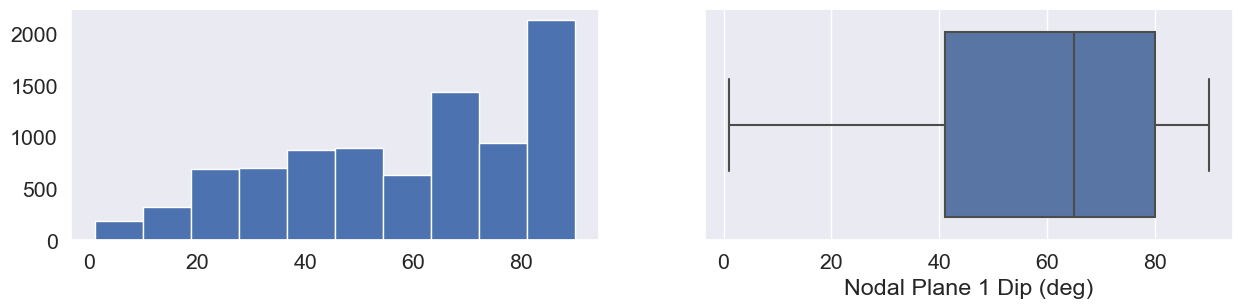

Column:  Nodal Plane 1 Rake Angle (deg)
Skew: -0.21
Kurtosis:  -1.06


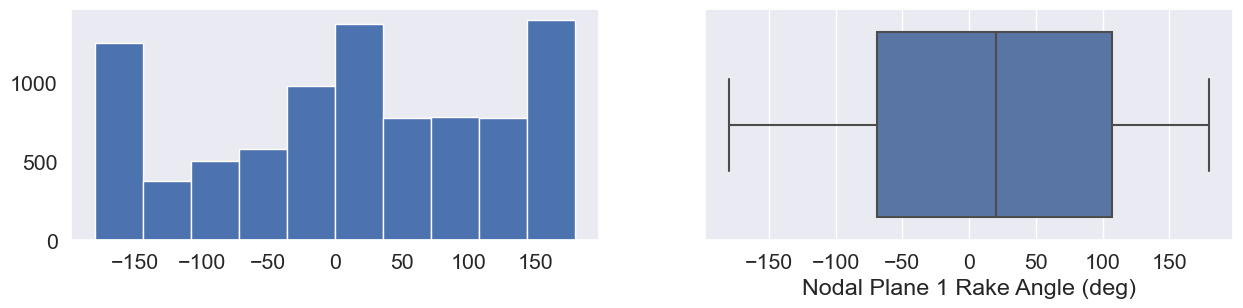

Column:  Nodal Plane 2 Strike (deg)
Skew: 0.08
Kurtosis:  -1.23


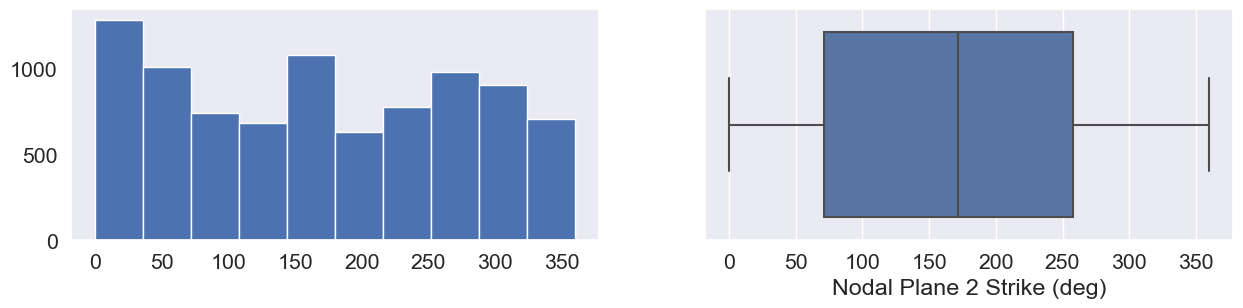

Column:  Nodal Plane 2 Dip (deg)
Skew: -0.82
Kurtosis:  0.54


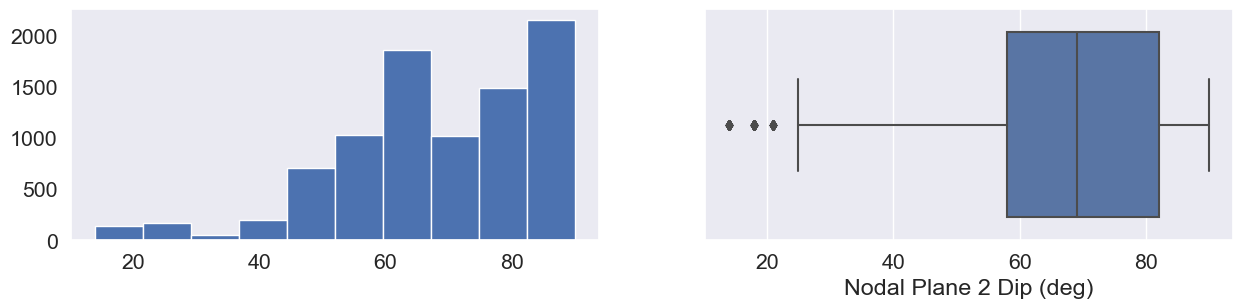

Column:  Nodal Plane 2 Rake Angle (deg)
Skew: -0.24
Kurtosis:  -0.92


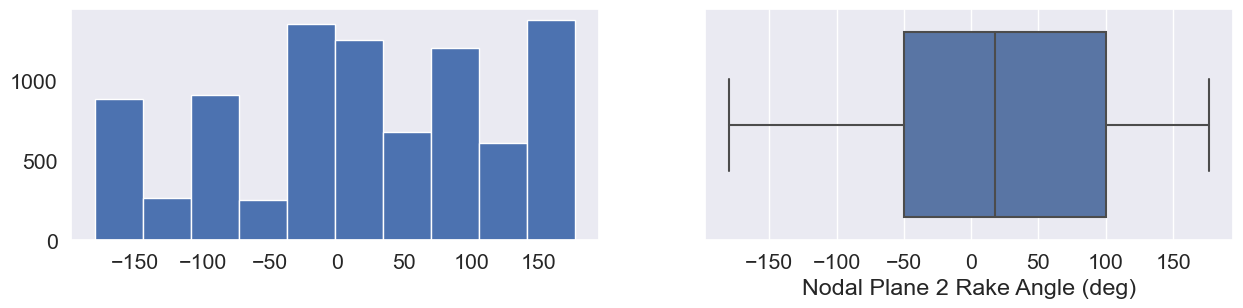

Column:  Fault Plane (1; 2; X)
Skew: 0.24
Kurtosis:  -1.94


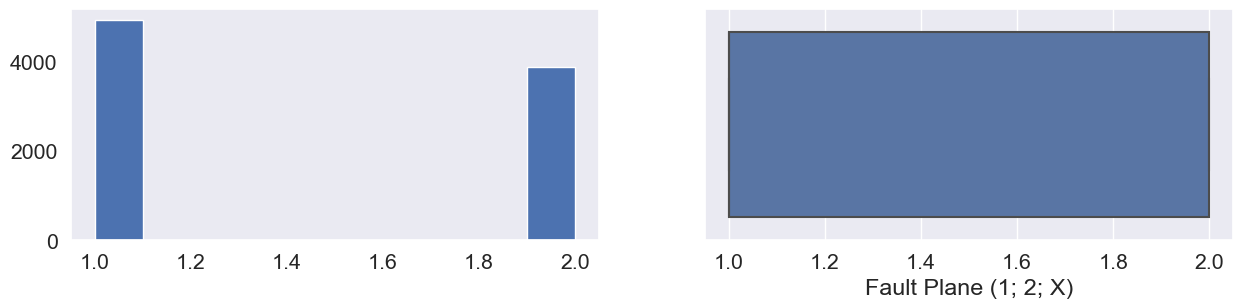

Column:  Station Latitude (deg positive N)
Skew: 0.6
Kurtosis:  0.2


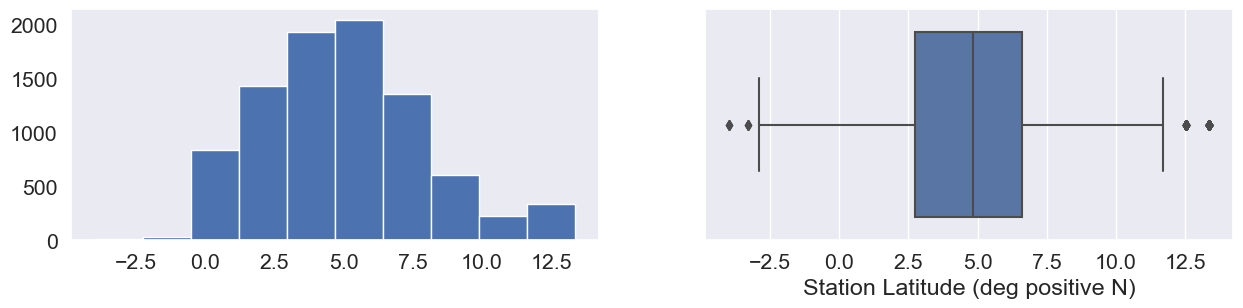

Column:  Station Longitude (deg positive E)
Skew: -0.43
Kurtosis:  0.73


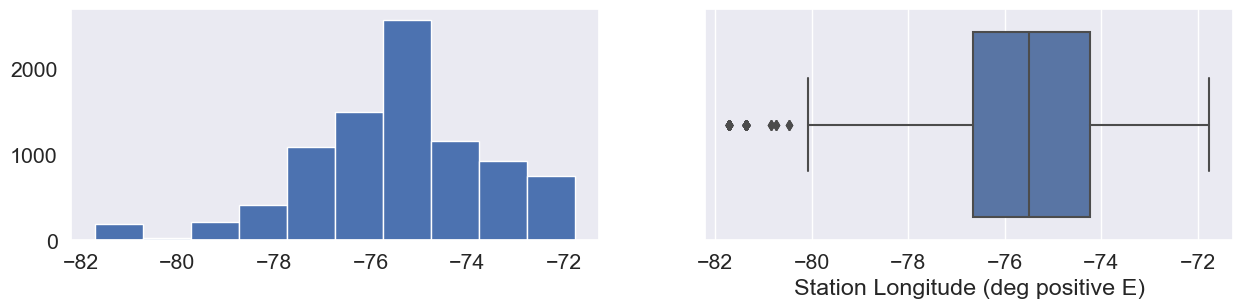

Column:  Station Elevation (m)
Skew: 0.93
Kurtosis:  -0.21


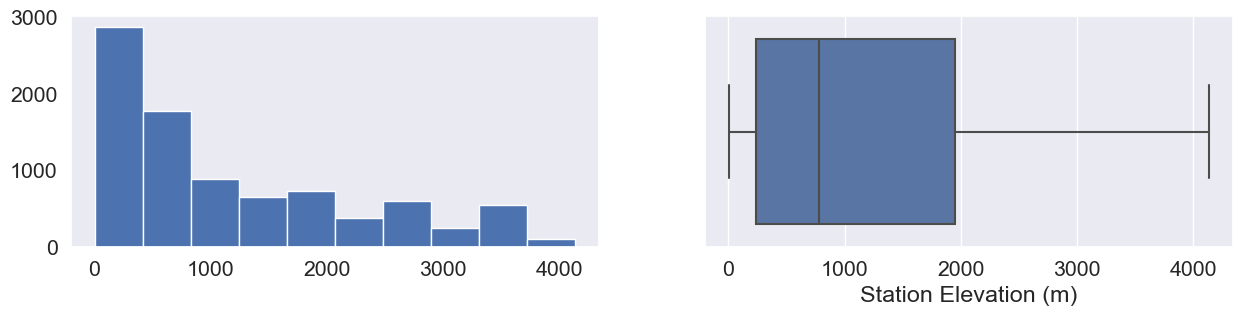

Column:  Tmax
Skew: 1.23
Kurtosis:  6.57


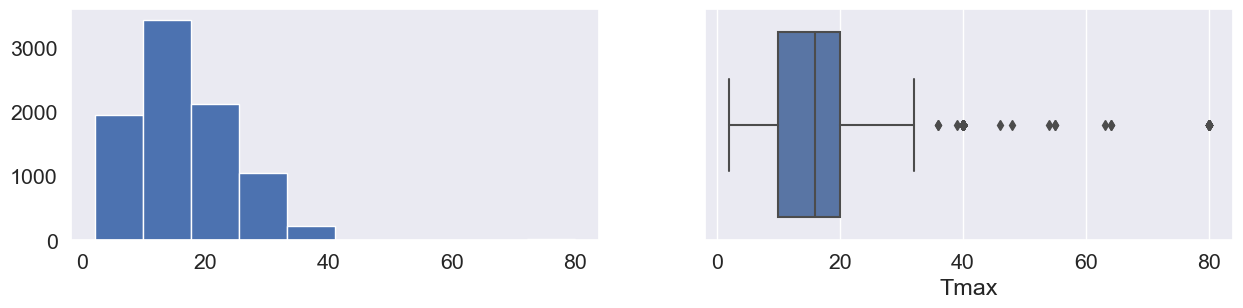

Column:  Valor_T1.5
Skew: 2.95
Kurtosis:  60.82


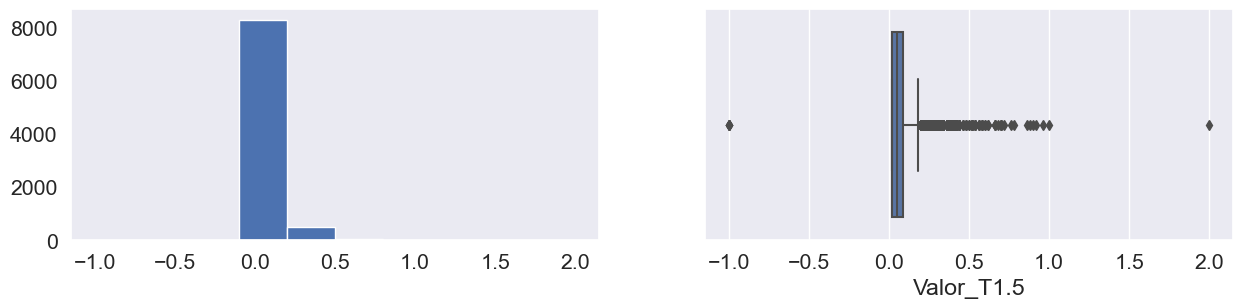

Column:  Repi_OpenQuake
Skew: 0.93
Kurtosis:  0.24


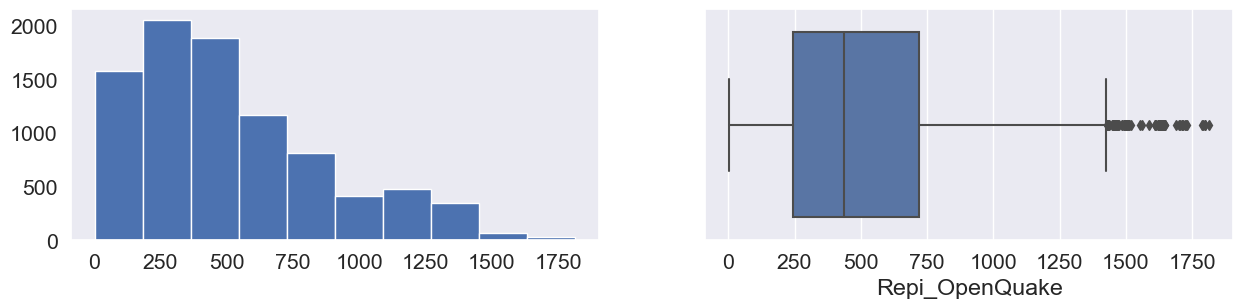

Column:  Rjb_OpenQuake
Skew: 0.92
Kurtosis:  0.22


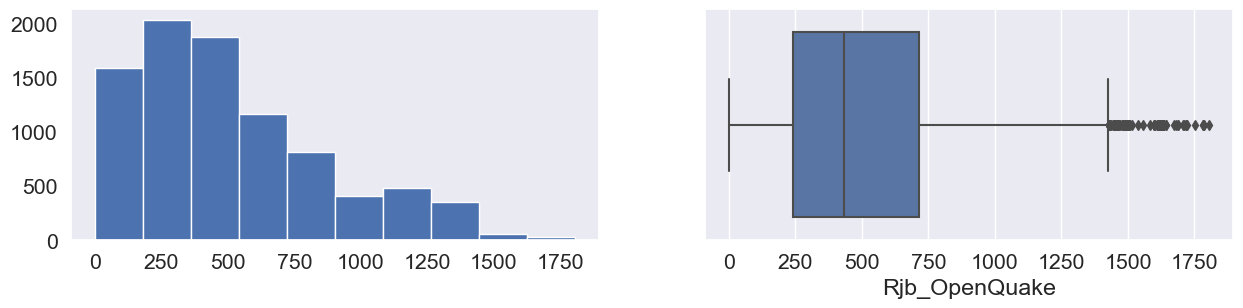

Column:  Rrup_OpenQuake
Skew: 0.99
Kurtosis:  0.33


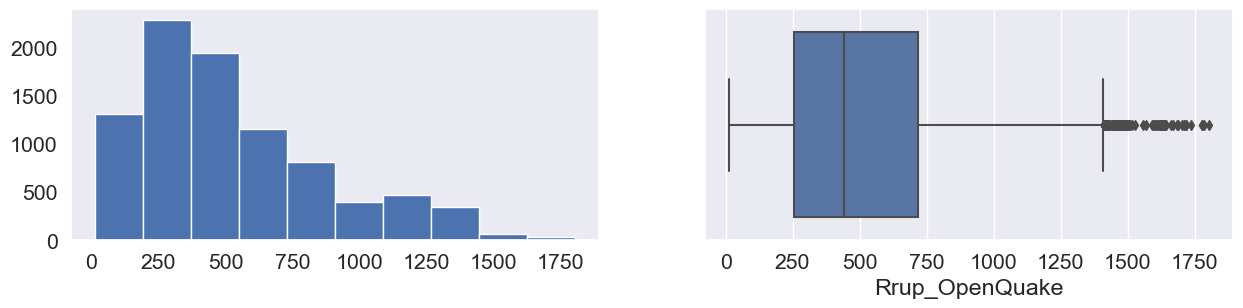

Column:  Rx_OpenQuake
Skew: -0.17
Kurtosis:  1.49


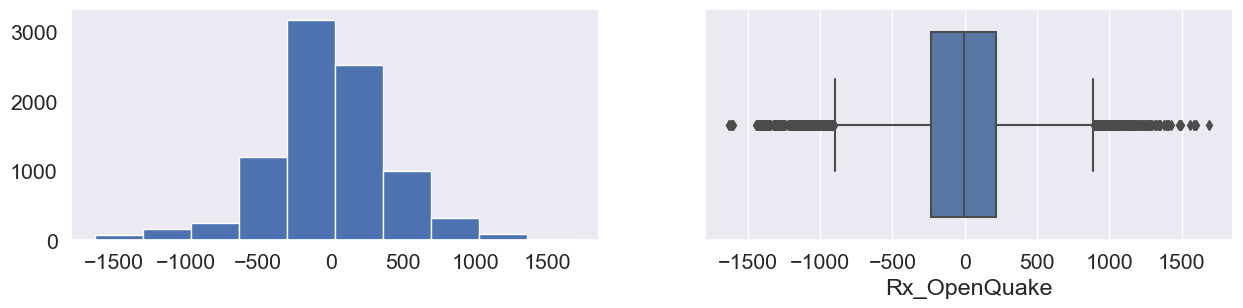

Column:  Rhypo_OpenQuake
Skew: 0.99
Kurtosis:  0.34


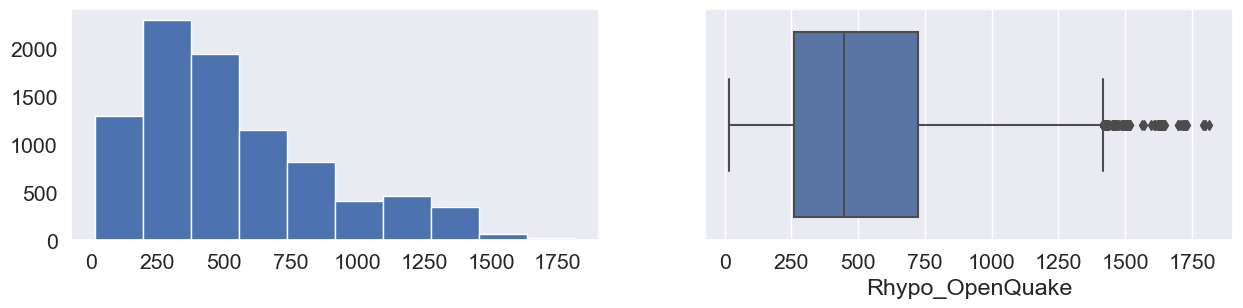

Column:  Ry0_OpenQuake
Skew: 1.37
Kurtosis:  1.76


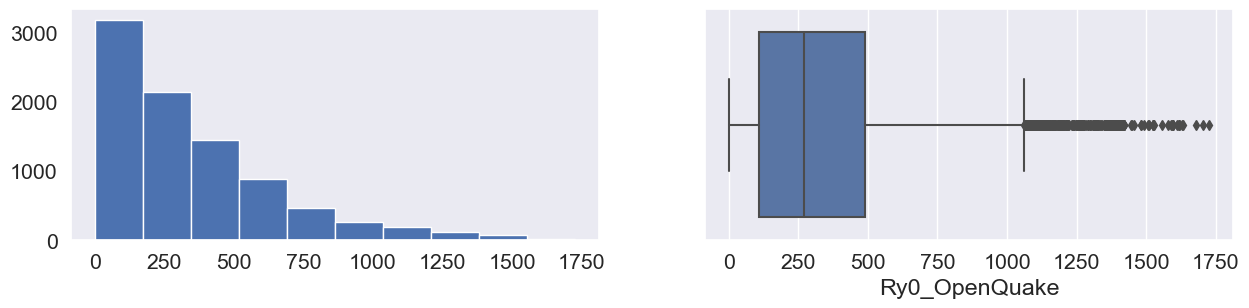

Column:  T_0.01_RotD50
Skew: 0.33
Kurtosis:  -0.44


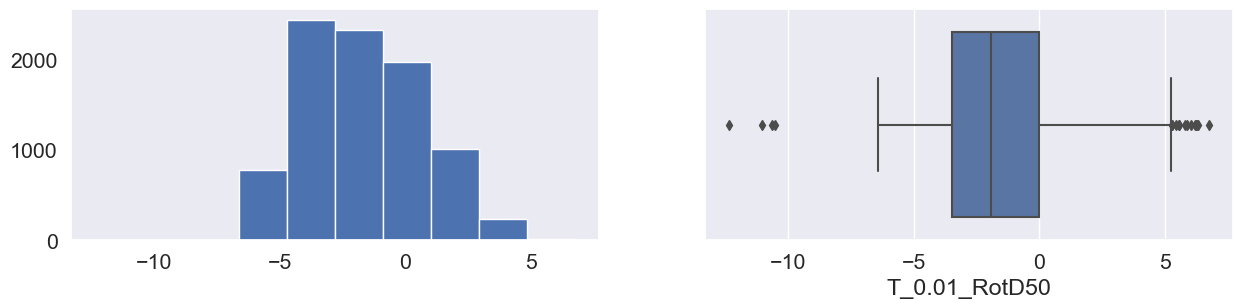

In [13]:
sns.set(font_scale=1.4)
num_cols = df_copy.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    print('Column: ', col)
    print('Skew:', round(df_copy[col].skew(), 2))
    print('Kurtosis: ', round(df_copy[col].kurtosis(), 2))
    plt.figure(figsize = (15, 3))
    plt.subplot(1, 2, 1)
    df_copy[col].hist(grid=False)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_copy[col])
    plt.show()

- **Variables categóricas**

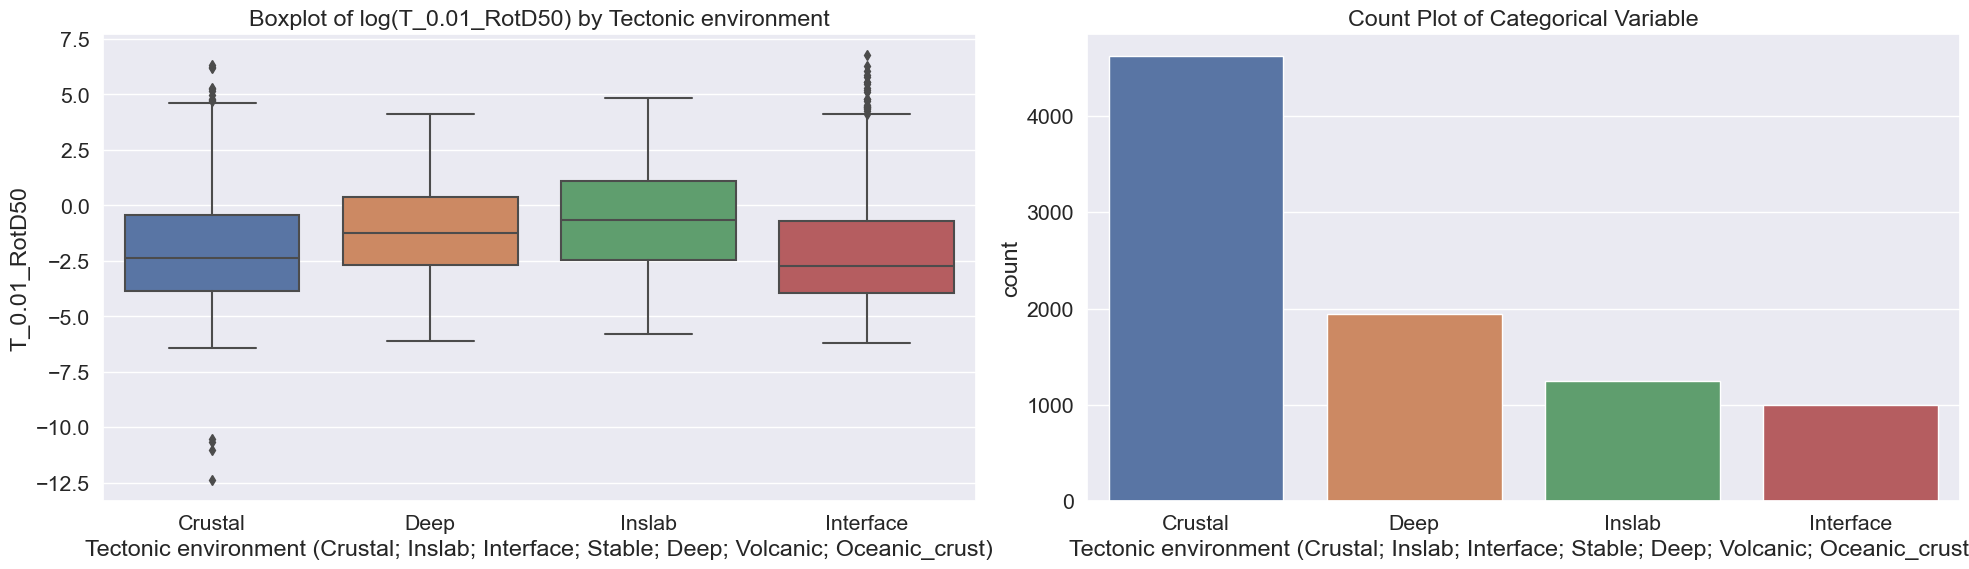

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6)) 
sns.boxplot(x=df_copy["Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"], y=df_copy["T_0.01_RotD50"], ax=axes[0])
axes[0].set_title("Boxplot of log(T_0.01_RotD50) by Tectonic environment")
sns.countplot(x=df_copy["Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"], ax=axes[1])
axes[1].set_title("Count Plot of Categorical Variable")
plt.tight_layout()
plt.show()

There is a lot more that you can do with outputs (such as including interactive outputs)
with your book. For more information about this, see [the Jupyter Book documentation](https://jupyterbook.org)